# Parcel Data Exploration

import pandas

In [15]:
import pandas as pd
import geopolars as gp
import polars as pl
import json
import seaborn as sns
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt

In [3]:
dataTypes = {
    "taxpayer_2": "string",
    "street_prefix": "string",
    "parcel_id": "string",
    "zip_code": "string",
    "zoning_district": "string",
    "landmap": "string",
    'subdivision': 'string',
    "local_historic_description": "string",
    "use_code_description": "string"
}

df = pd.read_csv('parcel-data-cleaned.csv', dtype=dataTypes)
df

/var/folders/_8/mj5qxln51q32j0tn2dfcv5br0000gn/T/ipykernel_85576/1048481345.py:13: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('parcel-data-cleaned.csv', dtype=dataTypes)


,object_id,parcel_id,address,zip_code,taxpayer_1,taxpayer_2,taxpayer_address,taxpayer_city,taxpayer_state,taxpayer_zip_code,...,subdivision,local_historic_district,neighborhood,council_district,street_number,street_prefix,street_name,object_id.1,shape_area,shape_length
0,243,02000184.,712 CASS,48226,"DETROIT CLUB HOLDINGS, LLC",<NA>,712 CASS AVE,DETROIT,MI,48226,...,<NA>,NaN,Downtown,6.0,712.0,<NA>,CASS,1,1541.785156,164.003882
1,244,02000154.,422 W CONGRESS,48226,"CHICKPEA DEVELOPMENT, LLC",<NA>,1900 NORTH BAYSHORE DR UNIT 4704,MIAMI,FL,33132,...,<NA>,NaN,Downtown,6.0,422.0,W,CONGRESS,2,1105.269531,266.823595
2,24808,18007432.,1302 CRAWFORD,48209,"NAVA, JOSE",<NA>,1228 CASGRAIN,DETROIT,MI,48209,...,<NA>,NaN,Central Southwest,6.0,1302.0,<NA>,CRAWFORD,3,619.589844,125.262340
3,245,02000155.,404 W CONGRESS,48226,623 CASS AVE. LLC,<NA>,146-18 LIBERTY AVE,JAMIACA,NY,11435,...,<NA>,NaN,Downtown,6.0,404.0,W,CONGRESS,4,2354.699219,196.556745
4,24809,18007150.,1573 LIVERNOIS,48209,"REYES-CISNEROS, EDGAR",<NA>,1573 LIVERNOIS AVE,DETROIT,MI,48209-2051,...,<NA>,NaN,Central Southwest,6.0,1573.0,<NA>,LIVERNOIS,5,690.312500,136.680155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378361,25378363,20003277-8,9203 AVIS,48209,"DUMONT, NILDA",<NA>,9203 AVIS ST,DETROIT,MI,48209-4404,...,JOHN P CLARK EST SUB,NaN,Springwells,6.0,9203.0,<NA>,AVIS,378370,764.160156,119.532694
378362,25378364,20003279.000,9215 AVIS,48209,"REYNA, ANTONIO",<NA>,9215 AVIS,DETROIT,MI,48209-4404,...,JOHN P CLARK EST SUB,NaN,Springwells,6.0,9215.0,<NA>,AVIS,378371,766.082031,119.625928
378363,25378365,05002946-7,967 KING,48211,"LINDY, JASON",<NA>,967 KING ST,DETROIT,MI,48211,...,CROWTONS SUB,NaN,North End,5.0,967.0,<NA>,KING,378372,1123.835938,140.268590
378364,25378366,17009440-1,5788 VAN DYKE,48213,11353 JACKSON AVE LLC,<NA>,5788 VAN DYKE,DETROIT,MI,48231,...,SHELLY & SIMPSONS SUB,NaN,Gratiot Town/Kettering,5.0,5788.0,<NA>,VAN DYKE,378373,1190.062500,143.156692


In [50]:
isR1 = df['zoning_district'] == 'R1'
isR2 = df['zoning_district'] == 'R2'
isR3 = df['zoning_district'] == 'R3'
isR4 = df['zoning_district'] == 'R4'
isR5 = df['zoning_district'] == 'R5'
isR6 = df['zoning_district'] == 'R6'

residential_zones = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']

isResidentiallyZoned = isR1 | isR2 | isR3 | isR4 | isR5 | isR6

isB1 = df['zoning_district'] == 'B1'
isB2 = df['zoning_district'] == 'B2'
isB3 = df['zoning_district'] == 'B3'
isB4 = df['zoning_district'] == 'B4'
isB5 = df['zoning_district'] == 'B5'
isB6 = df['zoning_district'] == 'B6'

commercial_zones = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6']

isCommerciallyZoned = isB1 | isB2 | isB3 | isB4 | isB5 | isB6

isM1 = df['zoning_district'] == 'M1'
isM2 = df['zoning_district'] == 'M2'
isM3 = df['zoning_district'] == 'M3'
isM4 = df['zoning_district'] == 'M4'
isM5 = df['zoning_district'] == 'M5'

industrial_zones = ['M1', 'M2', 'M3', 'M4', 'M5']

isIndustriallyZoned = isM1 | isM2 | isM3 | isM4 | isM5

special_zones = [ "SD1", "SD2", "SD4", "SD3", "SD5", "PCA", "PR", "P1", "PD", "PC", "TM", "MKT", "W1" ]

all_zones = residential_zones + commercial_zones + industrial_zones + special_zones

In [6]:
with open('zoning_districts.json', 'w') as f:
    json.dump(df['zoning_district'].unique().dropna().tolist(), f, indent=4)

In [7]:
with open('use_codes.json', 'w') as f:
    json.dump(df['use_code_description'].unique().dropna().tolist(), f, indent=4)

In [8]:
df.groupby(['zoning_district', 'use_code_description']).size().reset_index(name='counts').to_csv('zoning-use-code-counts.csv', index=False)

In [177]:
woodbridge = df['neighborhood'][lambda neighborhood: neighborhood == 'Woodbridge']

In [194]:
result = df.groupby(['use_code_description','zoning_district']).size().reset_index(name='count')

result['total_count'] = result.groupby('use_code_description')['count'].transform('sum')
result['percentage'] = (result['count'] / result['total_count']) * 100

# Create summary by use_code_description
summary = result.groupby('use_code_description').agg({
    'count': 'sum',  # Total count
    'percentage': 'max'  # Modal percentage
}).rename(columns={'percentage': 'modal_percentage'})

# Calculate overall average
avg_modal_percentage = summary['modal_percentage'].mean()

print(f"Average modal percentage: {avg_modal_percentage:.2f}%")
print("\nSummary:")

result[result['use_code_description'] == 'CARRIAGE HOUSE']

Average modal percentage: 55.71%

Summary:


,use_code_description,zoning_district,count,total_count,percentage
128,CARRIAGE HOUSE,R1,1,5,20.0
129,CARRIAGE HOUSE,R2,2,5,40.0
130,CARRIAGE HOUSE,R5,1,5,20.0
131,CARRIAGE HOUSE,SD2,1,5,20.0


In [185]:
import os

# Create output directory
os.makedirs('use_code_charts', exist_ok=True)

# Generate all charts
for i, use_code in enumerate(use_codes):
    if pd.notna(use_code):
        # Filter and sort data
        data = result[result['use_code_description'] == use_code].copy()
        data = data.sort_values('percentage', ascending=False)
        
        # Create chart
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(data)), data['percentage'])
        bars[0].set_color('darkred')
        
        plt.xlabel('Zoning District', fontsize=12)
        plt.ylabel('Percentage (%)', fontsize=12)
        plt.title(f'Zoning District Distribution for: {use_code}', fontsize=14, fontweight='bold')
        plt.xticks(range(len(data)), data['zoning_district'], rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        
        # Save
        filename = f"use_code_charts/{i:03d}_{use_code[:30].replace('/', '_')}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close()
        
print("\nAll charts saved to 'use_code_charts' directory")

Saved: use_code_charts/000_APT-FLAT GARDEN TYPE.png
Saved: use_code_charts/001_APT-FLAT SLAB TYPE.png
Saved: use_code_charts/002_APT-HI-RISE.png
Saved: use_code_charts/003_APT-W_ ELEVATOR.png
Saved: use_code_charts/004_APT-WALK UP.png
Saved: use_code_charts/005_ASSISTED LIVING RESIDENCE.png
Saved: use_code_charts/006_AUTO SALE W_SERVICE.png
Saved: use_code_charts/007_BANK BRANCH.png
Saved: use_code_charts/008_BANK MINI (WALK-UP & DRIVE-THR.png
Saved: use_code_charts/009_BAR.png
Saved: use_code_charts/010_BARBER, BEAUTY SHOP.png
Saved: use_code_charts/011_BOAT HOUSE.png
Saved: use_code_charts/012_BOWLING CENTER.png
Saved: use_code_charts/013_BOWLING CENTER W_RESTURANT.png
Saved: use_code_charts/014_CARRIAGE HOUSE.png
Saved: use_code_charts/015_CARWASH.png
Saved: use_code_charts/016_CASINO.png
Saved: use_code_charts/017_CELLULAR TOWER.png
Saved: use_code_charts/018_CHILD CARE CENTER.png
Saved: use_code_charts/019_COMMERCIAL HALL.png
Saved: use_code_charts/020_COOPERATIVE.png
Saved: use_c

In [180]:
neighborhood_df = df[ (df['neighborhood'] == 'Mexicantown') | (df['neighborhood'] == 'Hubbard Farms')]

In [137]:
neighborhood_df.head()

,object_id,parcel_id,address,zip_code,taxpayer_1,taxpayer_2,taxpayer_address,taxpayer_city,taxpayer_state,taxpayer_zip_code,...,subdivision,local_historic_district,neighborhood,council_district,street_number,street_prefix,street_name,object_id,shape_area,shape_length
273033,24311106,14009472-8,1011 HUBBARD,48209,"JANKOWSKI, GERALD A",<NA>,4020 LAFAYETTE BLVD,DETROIT,MI,48209-3246,...,<NA>,Hubbard Farms,Hubbard Farms,6.0,1011.0,<NA>,HUBBARD,273038,2655.812500,229.625379
273039,24311113,14000230.,4075 PORTER,48209,"ANGULO, MIGUEL & ANGULO-TORRES, S.",<NA>,4081 PORTER ST,DETROIT,MI,48209-2430,...,<NA>,Hubbard Farms,Hubbard Farms,6.0,4075.0,<NA>,PORTER,273044,717.152344,141.013097
273040,24311114,14009448.002L,1461 HUBBARD,48209,"RODRIGUEZ, PABLO & GIOVANNA",<NA>,1510 HUBBARD,DETROIT,MI,48209,...,<NA>,Hubbard Farms,Hubbard Farms,6.0,1461.0,<NA>,HUBBARD,273045,975.125000,174.607222
273041,24311115,14009288.,1536 HUBBARD,48216,"ATKINSON, ASHLEY",<NA>,1536 HUBBARD ST,DETROIT,MI,48209-3317,...,<NA>,Hubbard Farms,Hubbard Farms,6.0,1536.0,<NA>,HUBBARD,273046,1027.726562,171.009458
273042,24311116,14009449.,1453 HUBBARD,48209,HUBBARD FARMS APARTMENTS LDHALP,<NA>,3627 W VERNOR,DETROIT,MI,48216,...,<NA>,Hubbard Farms,Hubbard Farms,6.0,1453.0,<NA>,HUBBARD,273047,1993.164062,202.065761


/var/folders/_8/mj5qxln51q32j0tn2dfcv5br0000gn/T/ipykernel_12742/2875435866.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # Rotate by 45 degrees, align right


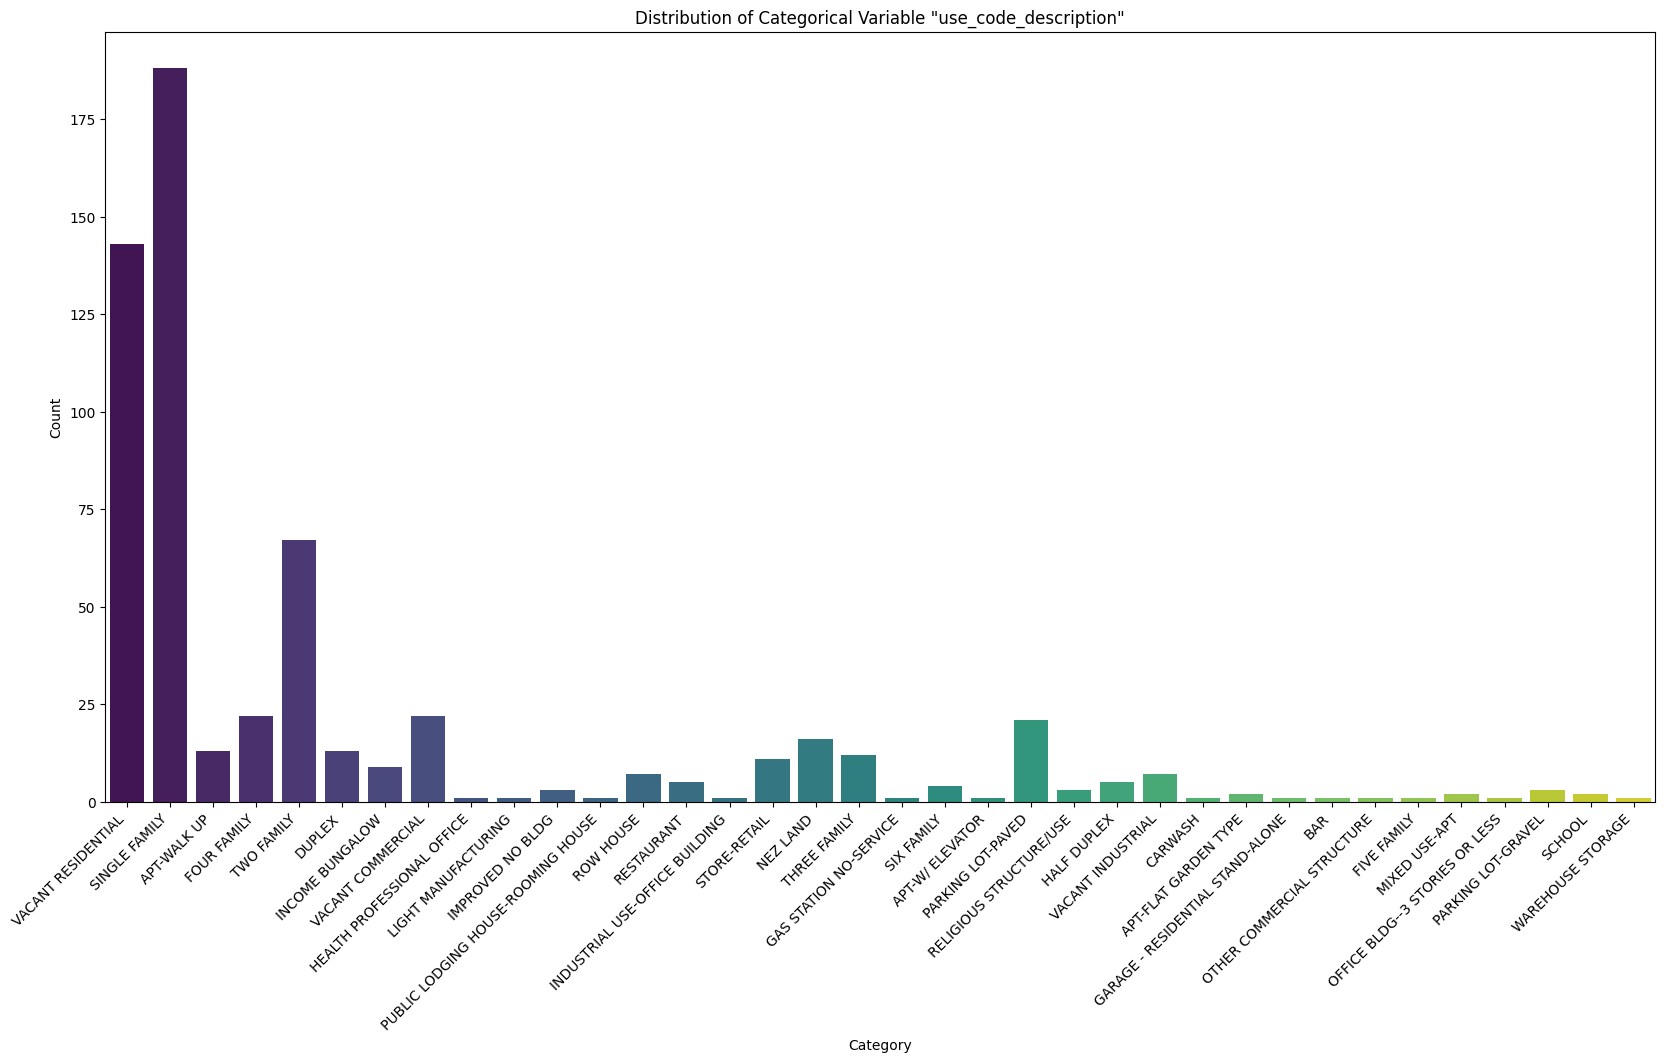

In [138]:


# Create a count plot
plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
ax = sns.countplot(x='use_code_description', data=neighborhood_df, palette='viridis', hue='use_code_description', legend=False) # 'x' specifies the categorical variable
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # Rotate by 45 degrees, align right
plt.title('Distribution of Categorical Variable "use_code_description"')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378366 entries, 0 to 378365
Data columns (total 52 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   object_id                                      378366 non-null  int64  
 1   parcel_id                                      378366 non-null  string 
 2   address                                        378334 non-null  object 
 3   zip_code                                       376721 non-null  string 
 4   taxpayer_1                                     378332 non-null  object 
 5   taxpayer_2                                     12420 non-null   string 
 6   taxpayer_address                               378312 non-null  object 
 7   taxpayer_city                                  377369 non-null  object 
 8   taxpayer_state                                 377362 non-null  object 
 9   taxpayer_zip_code                    

In [88]:
EMPTY_ZONING_DISTRICTS_TEMPLATE = {
    "conditional": [],
    "by_right": [],
    "by_right_subject_to_conditions": []
}

zoning_uses = json.load(open('detroit_zoning.json'))

def unionZoningMaps(map1, map2):
    return {
        key: list(set(map1.get(key, []) + map2.get(key, [])))
        for key in EMPTY_ZONING_DISTRICTS_TEMPLATE
    }

def getZoningDistrictsFromUses(use_category, specific_uses):
    
    zoning_districts = EMPTY_ZONING_DISTRICTS_TEMPLATE.copy()
    
    if use_category == 'Residential':
        zoning_districts['by_right'] = residential_zones
    elif use_category == 'Commercial':
        zoning_districts['by_right'] = commercial_zones
    elif use_category == 'Industrial':
        zoning_districts['by_right'] = industrial_zones
    elif use_category == 'All':
        zoning_districts['by_right'] = all_zones
    else:
        for specific_use in specific_uses:
            zoning_districts = unionZoningMaps(zoning_districts, zoning_uses[use_category][specific_use])
            
    return zoning_districts   

mapped_use_codes = json.load(open('parcel_use_codes_to_zoning_use_codes_manual_mapping.json'))

extended_mapped_use_codes = {}

for parcel_use_code, mappings in mapped_use_codes.items():
          
    extended_mapped_use_codes[parcel_use_code] = {
        'parcel_uses': mappings,
        'zoning_districts': EMPTY_ZONING_DISTRICTS_TEMPLATE.copy()
    }

    for mapping in mappings:
        specific_use_zoning_districts = getZoningDistrictsFromUses(
            mapping['use_category'], 
            mapping['specific_use']
        )
        
        extended_mapped_use_codes[parcel_use_code]['zoning_districts'] = unionZoningMaps(
            extended_mapped_use_codes[parcel_use_code]['zoning_districts'], 
            specific_use_zoning_districts
        )

json.dump(extended_mapped_use_codes, open('parcel_use_codes_to_zoning_districts_mapping.json', 'w'), indent=4)

In [89]:
df['by_right_zoning_districts'] = df['use_code_description'].apply(
    lambda use_code: extended_mapped_use_codes.get(use_code, {}).get('zoning_districts', {}).get('by_right', [])
)
df['conditional_zoning_districts'] = df['use_code_description'].apply(
    lambda use_code: extended_mapped_use_codes.get(use_code, {}).get('zoning_districts', {}).get('conditional', [])
)
df['special_approval_zoning_districts'] = df['use_code_description'].apply(
    lambda use_code: extended_mapped_use_codes.get(use_code, {}).get('zoning_districts', {}).get('by_right_subject_to_conditions', [])
)

In [90]:
df['is_zoned_by_right'] = df.apply(
    lambda row: row['zoning_district'] in row['by_right_zoning_districts'] 
    if pd.notna(row['zoning_district'])
    else False,
    axis=1
)

df['is_zoned_conditionally'] = df.apply(
    lambda row: row['zoning_district'] in row['conditional_zoning_districts']
    if pd.notna(row['zoning_district'])
    else False,
    axis=1
)

df['is_zoned_special_approval'] = df.apply(
    lambda row: row['zoning_district'] in row['special_approval_zoning_districts']
    if pd.notna(row['zoning_district'])
    else False,
    axis=1
)

In [86]:
df['is_non_conforming'] = ~(df['is_zoned_by_right'] | df['is_zoned_conditionally'] | df['is_zoned_special_approval'])

In [ ]:
non_conforming_df = df[df['is_non_conforming']]
df.to_csv('all_parcels.csv', index=False)
non_conforming_df.to_csv('non_conforming_parcels.csv', index=False)

,object_id,parcel_id,address,zip_code,taxpayer_1,taxpayer_2,taxpayer_address,taxpayer_city,taxpayer_state,taxpayer_zip_code,...,shape_area,shape_length,mapped_use_categories,by_right_zoning_districts,conditional_zoning_districts,special_approval_zoning_districts,is_zoned_by_right,is_zoned_conditionally,is_zoned_special_approval,is_non_conforming
3,245,02000155.,404 W CONGRESS,48226,623 CASS AVE. LLC,<NA>,146-18 LIBERTY AVE,JAMIACA,NY,11435,...,2354.699219,196.556745,[{'use_category': 'Warehouse and freight movem...,"[M1, M3, M5, M2, M4, MKT, TM, B6]","[M1, B4, SD4, W1, M5, M4, B5, M2]",[MKT],False,False,False,True
38,24843,18007124.,1807 LIVERNOIS,48209,LOMELI FONSECA LLC,<NA>,22057 BEECH DALY RD,BROWNSTOWN,MI,48134,...,900.035156,150.142960,"[{'use_category': 'Food and beverage service',...","[M3, M1, B4, SD4, B6, B3, PCA, SD2, B2, SD1, M...","[M1, M3, B4, SD4, B3, B5, PCA, B2, M4, M2, B6]","[B4, B3, PCA, B2, B5]",False,False,False,True
61,24871,18007127.,1793 LIVERNOIS,48209,LOMELI FONSECA LLC,<NA>,22057BEECH DALY,BROWNSTOWN,MI,48134,...,695.398438,136.737381,NaN,[],[],[],False,False,False,True
81,24893,18007128.,1787 LIVERNOIS,48209,LOMELI FONSECA LLC,<NA>,22057 BEECH DALY,BROWNSTOWN,MI,48134,...,695.382812,136.737345,NaN,[],[],[],False,False,False,True
83,24895,18007129.,1781 LIVERNOIS,48209,LOMELI FONSECA LLC,<NA>,22057 BEECH DALY,BROWNTOWN,MI,48134,...,691.175781,136.920951,NaN,[],[],[],False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378361,25378363,20003277-8,9203 AVIS,48209,"DUMONT, NILDA",<NA>,9203 AVIS ST,DETROIT,MI,48209-4404,...,764.160156,119.532694,"[{'use_category': 'Household living', 'specifi...","[R2, R5, R1, R3, R4]","[B4, B1, R6, B2, SD1]",[],False,False,False,True
378362,25378364,20003279.000,9215 AVIS,48209,"REYNA, ANTONIO",<NA>,9215 AVIS,DETROIT,MI,48209-4404,...,766.082031,119.625928,"[{'use_category': 'Residential', 'specific_use...","[M3, B3, SD1, MKT, B5, R2, B4, P1, SD2, B2, R3...",[],[],False,False,False,True
378363,25378365,05002946-7,967 KING,48211,"LINDY, JASON",<NA>,967 KING ST,DETROIT,MI,48211,...,1123.835938,140.268590,"[{'use_category': 'Household living', 'specifi...","[R2, R5, R1, R3, R4]","[B4, B1, R6, B2, SD1]",[],False,False,False,True
378364,25378366,17009440-1,5788 VAN DYKE,48213,11353 JACKSON AVE LLC,<NA>,5788 VAN DYKE,DETROIT,MI,48231,...,1190.062500,143.156692,[{'use_category': 'Vehicle service and repair'...,[],"[M3, M1, B4, SD2, M5, M4, M2, B6]",[],False,False,False,True


,object_id,parcel_id,address,zip_code,taxpayer_1,taxpayer_2,taxpayer_address,taxpayer_city,taxpayer_state,taxpayer_zip_code,...,shape_area,shape_length,mapped_use_categories,by_right_zoning_districts,conditional_zoning_districts,special_approval_zoning_districts,is_zoned_by_right,is_zoned_conditionally,is_zoned_special_approval,is_non_conforming
3,245,02000155.,404 W CONGRESS,48226,623 CASS AVE. LLC,<NA>,146-18 LIBERTY AVE,JAMIACA,NY,11435,...,2354.699219,196.556745,[{'use_category': 'Warehouse and freight movem...,"[M1, M3, M5, M2, M4, MKT, TM, B6]","[M1, B4, SD4, W1, M5, M4, B5, M2]",[MKT],False,False,False,True
16,24818,16000258.,5809 W FORT,48209,20450 SANTA BARBARA LLC,<NA>,5809 W FORT,DETROIT,MI,48209,...,498.214844,117.487644,"[{'use_category': 'Commercial', 'specific_use'...","[B4, B1, B3, B2, B5, B6]",[],[],False,False,False,True
17,24819,16000200.,5838 ANTHON,48209,"HIXSON, CHARLES L",<NA>,5838 ANTHON,DETROIT,MI,48209,...,530.210938,123.763384,"[{'use_category': 'Residential', 'specific_use...","[R2, R5, R6, R1, R3, R4]",[],[],False,False,False,True
38,24843,18007124.,1807 LIVERNOIS,48209,LOMELI FONSECA LLC,<NA>,22057 BEECH DALY RD,BROWNSTOWN,MI,48134,...,900.035156,150.142960,"[{'use_category': 'Food and beverage service',...","[M3, M1, B4, SD4, B6, B3, PCA, SD2, B2, SD1, M...","[M1, M3, B4, SD4, B3, B5, PCA, B2, M4, M2, B6]","[B4, B3, PCA, B2, B5]",False,False,False,True
56,24862,16014418.,347 CAMPBELL,48209,"City of Detroit P&DD, Care of DBA",<NA>,"2 WOODWARD AVENUE, SUITE 808",DETROIT,MI,48226,...,404.085938,86.309646,"[{'use_category': 'Residential', 'specific_use...","[R2, R5, R6, R1, R3, R4]",[],[],False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378361,25378363,20003277-8,9203 AVIS,48209,"DUMONT, NILDA",<NA>,9203 AVIS ST,DETROIT,MI,48209-4404,...,764.160156,119.532694,"[{'use_category': 'Household living', 'specifi...","[R2, R5, R1, R3, R4]","[B4, B1, R6, B2, SD1]",[],False,False,False,True
378362,25378364,20003279.000,9215 AVIS,48209,"REYNA, ANTONIO",<NA>,9215 AVIS,DETROIT,MI,48209-4404,...,766.082031,119.625928,"[{'use_category': 'Residential', 'specific_use...","[R2, R5, R6, R1, R3, R4]",[],[],False,False,False,True
378363,25378365,05002946-7,967 KING,48211,"LINDY, JASON",<NA>,967 KING ST,DETROIT,MI,48211,...,1123.835938,140.268590,"[{'use_category': 'Household living', 'specifi...","[R2, R5, R1, R3, R4]","[B4, B1, R6, B2, SD1]",[],False,False,False,True
378364,25378366,17009440-1,5788 VAN DYKE,48213,11353 JACKSON AVE LLC,<NA>,5788 VAN DYKE,DETROIT,MI,48231,...,1190.062500,143.156692,[{'use_category': 'Vehicle service and repair'...,[],"[M3, M1, B4, SD2, M5, M4, M2, B6]",[],False,False,False,True


In [11]:
buildable_df = gp.read_file('parcels_with_buildability.gpkg')
buildable_df.head()

object_id,parcel_number,ward,address,council_district,zip_code,taxpayer_1,taxpayer_2,taxpayer_street,taxpayer_city,taxpayer_state,taxpayer_zip,property_class,property_class_desc,property_class_previous,use_code,use_code_desc,tax_status,tax_status_description,tax_status_previous,total_square_footage,total_acreage,frontage,depth,homestead_pre,nez,is_improved,num_bldgs,total_floor_area,style,year_built,sale_price,sale_date,assessed_value,assessed_value_previous,taxable_value,taxable_value_previous,economic_condition_factor_neigh,landmap,related,zoning,historic_designation,subdivision,legal_description,Shape__Area,Shape__Length,isBuildable,geometry
i32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,null,null,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,"datetime[ms, UTC]",f64,f64,f64,f64,str,str,str,str,str,str,str,f64,f64,bool,binary
1,"""04000119.""","""4""","""541 W LAFAYETTE""","""6""","""48226""","""SHEHAN, JOSEPH & LOUISE & WAYN…","""KEARNEY, GAIL & GARCEAU, LYLA""","""3370 ROCKYCRUST""","""ROCHESTER HILLS""","""MI""","""48306""","""202""","""COMMERCIAL-VACANT""","""202""",null,null,"""TAXABLE""","""TAXABLE""","""TAXABLE""",13983.0,0.321,100.0,140.0,0.0,"""""",0.0,0.0,null,null,null,0.0,null,682100.0,681400.0,197316.0,187920.0,null,"""001""",null,"""B5""",null,"""""","""S W LAFAYETTE 5&6 AND N 10 FT …",1.3352e-7,0.001486,true,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00+\xc3\xba\xcco\xc3T\xc0\x98\x19%\xea\x1d*E@J`\xc7\xf1k\xc3T\xc0f%\xfb\xdb\x13*E@\xcd\x86Q\x91f\xc3""…"
2,"""04000114-5""","""4""","""526 W FORT""","""6""","""48226""","""FORT STREET PRESBYTERIAN CHURC…","""""","""631 W FORT ST""","""DETROIT""","""MI""","""48226-3106""","""202""","""COMMERCIAL-VACANT""","""202""",null,null,"""EXEMPT (211.7S)""","""HOUSES OF PUBLIC WORSHIP; PARS…","""EXEMPT (211.7S)""",17511.0,0.402,125.0,140.0,0.0,"""""",0.0,0.0,null,null,null,0.0,null,0.0,0.0,0.0,0.0,null,"""001""",null,"""B5""",null,"""""","""N W FORT 7-8 W 25 FT OF 9 AND …",1.6814e-7,0.001671,true,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00\x06\x00\x00\x00\xcb\xf7\x88Lk\xc3T\xc0R\x16\xc1$\x12*E@['\x96Hg\xc3T\xc0\xf24Y\x06\x08*E@\xbb\x85\xe4`a\xc3""…"
3,"""02000184.""","""2""","""712 CASS""","""6""","""48226""","""DETROIT CLUB HOLDINGS, LLC""","""""","""712 CASS AVE""","""DETROIT""","""MI""","""48226""","""201""","""COMMERCIAL-IMPROVED""","""201""",null,null,"""TAXABLE""","""TAXABLE""","""TAXABLE""",9100.0,0.209,70.0,130.0,0.0,"""""",1.0,1.0,29191.0,"""City Clubs""",1904.0,1e6,2013-12-30 00:00:00 UTC,1.8553e6,1.7269e6,235482.0,224269.0,null,"""001""",null,"""PCA""",null,"""""","""N FORT 3 W 17 FT 4 MILITARY RE…",9.1980e-8,0.001266,true,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xa6\x88\xeb\xa9B\xc3T\xc0\xfc\x94\x09A5*E@D\xd3\x9c\xce>\xc3T\xc0\xdd:\x03Y+*E@i*\x9c\x03;\xc3""…"
4,"""02000154.""","""2""","""422 W CONGRESS""","""6""","""48226""","""CHICKPEA DEVELOPMENT, LLC""","""""","""1900 NORTH BAYSHORE DR UNIT 47…","""MIAMI""","""FL""","""33132""","""201""","""COMMERCIAL-IMPROVED""","""201""",null,null,"""TAXABLE""","""TAXABLE""","""TAXABLE""",5489.0,0.126,40.0,138.0,0.0,"""""",1.0,2.0,22048.0,"""Office Buildings""",1923.0,565000.0,2013-04-19 00:00:00 UTC,995200.0,937500.0,379505.0,361434.0,null,"""001""",null,"""PCA""",null,"""""","""N W CONGRESS TRIANG PT OF 13 B…",6.5940e-8,0.001979,true,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00\x09\x00\x00\x00\xe4t\x81\x1bB\xc3T\xc0\xa8}|\xd9\x0c*E@\x0aZ\x80\xe3@\xc3T\xc0d\xe35\xbf\x09*E@\x06/\x93\xd9A\xc3""…"
5,"""02000155.""","""2""","""404 W CONGRESS""","""6""","""48226""","""623 CASS AVE. LLC""","""""","""146-18 LIBERTY AVE""","""JAMIACA""","""NY""","""11435""","""201""","""COMMERCIAL-IMPROVED""","""201""",null,null,"""TAXABLE""","""TAXABLE""","""TAXABLE""",13800.0,0.317,100.0,138.0,0.0,"""""",1.0,2.0,96600.0,"""Bar Cocktail Lounges""",1905.0,1.12e6

In [16]:
buildable_df.filter(pl.col('parcel_number') == '21000535-54')

object_id,parcel_number,ward,address,council_district,zip_code,taxpayer_1,taxpayer_2,taxpayer_street,taxpayer_city,taxpayer_state,taxpayer_zip,property_class,property_class_desc,property_class_previous,use_code,use_code_desc,tax_status,tax_status_description,tax_status_previous,total_square_footage,total_acreage,frontage,depth,homestead_pre,nez,is_improved,num_bldgs,total_floor_area,style,year_built,sale_price,sale_date,assessed_value,assessed_value_previous,taxable_value,taxable_value_previous,economic_condition_factor_neigh,landmap,related,zoning,historic_designation,subdivision,legal_description,Shape__Area,Shape__Length,isBuildable,geometry
i32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,null,null,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,"datetime[ms, UTC]",f64,f64,f64,f64,str,str,str,str,str,str,str,f64,f64,bool,binary
357283,"""21000535-54""","""21""","""11901 E JEFFERSON""","""4""","""48214""","""FCA US LLC""","""CIMS 485-12-30""","""1000 CHRYSLER DR""","""AUBURN HILLS""","""MI""","""48326-2766""","""301""","""INDUSTRIAL-IMPROVED""","""301""",null,null,"""TAXABLE""","""TAXABLE""","""TAXABLE""",1.2083e7,277.377,0.0,0.0,0.0,"""""",1.0,22.0,2.958207e6,"""Industrial - Heavy Manufacturi…",1990.0,0.0,null,3.56257e7,3.54621e7,2.7943802e7,2.6613145e7,null,"""523""","""23002019.131""","""M4""",null,"""""","""N E JEFFERSON PART OF LOTS 1 T…",0.000123,0.057569,true,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00$\x00\x00\x00\xa5\x01\x819\xee\xbdT\xc0\x9e\xf5[\x0c'/E@cl\xff\xbe\xc2\xbdT\xc0\xe5\x8dliG/E@c\xcdW\x90\xad\xbd""…"
402192,"""21000535-54""","""21""","""11901 E JEFFERSON""","""4""","""48214""","""FCA US LLC""","""CIMS 485-12-30""","""1000 CHRYSLER DR""","""AUBURN HILLS""","""MI""","""48326-2766""","""301""","""INDUSTRIAL-IMPROVED""","""301""",null,null,"""TAXABLE""","""TAXABLE""","""TAXABLE""",1.2083e7,277.377,0.0,0.0,0.0,"""""",1.0,22.0,2.958207e6,"""Industrial - Heavy Manufacturi…",1990.0,0.0,null,3.54621e7,3.27968e7,2.6613145e7,2.5345853e7,"""IGIG2""","""523""","""23002019.131""","""R1""",null,"""""","""N E JEFFERSON PART OF LOTS 1 T…",0.000123,0.057569,false,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00""\x00\x00\x00\xc2~\x999\xee\xbdT\xc0iC\xb4\x0c'/E@\x19\xd1,\xbf\xc2\xbdT\xc0C\x1dKiG/E@6\x03\\x90\xad\xbd""…"
